# 🛡️ End-to-End Email Threat Classification
**Domain:** Cybersecurity  
**ML Task:** Binary Classification (Routine vs. Potentially Threatening)  
**Author:** Atanu Das

---
### 📌 Project Objective
Develop a zero-cost, reproducible machine learning solution that investigates email metadata characteristics, prepares and cleans the data, evaluates foundational models (Logistic Regression, KNN, Decision Tree), interprets metrics (F1-score, Recall, ROC-AUC, Confusion Matrix), and demonstrates inference through an interactive Streamlit application.


## 1. Environment Setup & Dependency Imports

In [1]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, roc_curve, classification_report
)
import joblib

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['font.size'] = 11
print("Libraries imported successfully!")


Libraries imported successfully!


## 2. Dataset Loading & Exploratory Data Analysis (EDA)
We inspect raw email records containing observable characteristics: `message_length`, `url_count`, `attachment_count`, `keyword_indicators`, `domain_age_days`, `suspicious_tld`, `spf_dkim_passed`, `uppercase_ratio`, and `has_external_links`.


In [2]:
df_raw = pd.read_csv('data/raw_email_threat_dataset.csv')
print(f"Raw Dataset Shape: {df_raw.shape}")
df_raw.head()


Raw Dataset Shape: (3500, 10)


,message_length,url_count,attachment_count,keyword_indicators,domain_age_days,suspicious_tld,spf_dkim_passed,uppercase_ratio,has_external_links,is_threat
0,1113.0,2,0,0,835.0,0,1,0.0252,1,0
1,547.0,6,1,5,18.0,1,0,0.3532,1,1
2,347.0,5,2,2,281.0,1,1,0.1828,1,1
3,1087.0,1,0,0,182.0,0,1,0.0684,1,0
4,788.0,1,1,0,196.0,0,1,0.0349,1,0


In [3]:
print("--- Missing Values Count ---")
print(df_raw.isnull().sum())
print("\n--- Target Class Balance ---")
print(df_raw['is_threat'].value_counts(normalize=True))


--- Missing Values Count ---
message_length        53
url_count              0
attachment_count       0
keyword_indicators     0
domain_age_days       67
suspicious_tld         0
spf_dkim_passed        0
uppercase_ratio        0
has_external_links     0
is_threat              0
dtype: int64

--- Target Class Balance ---
is_threat
0    0.646571
1    0.353429
Name: proportion, dtype: float64


## 3. Data Cleaning & Feature Engineering Pipeline
- Median imputation for missing values in continuous variables (`message_length`, `domain_age_days`)
- Standard scaling for distance/gradient based models (Logistic Regression, KNN)
- Stratified 80/20 train-test split


In [4]:
from src.data_preprocessing import prepare_train_test_data, FEATURE_COLS, TARGET_COL

X_train, X_test, X_train_s, X_test_s, y_train, y_test, scaler = prepare_train_test_data()
print(f"X_train shape: {X_train.shape}, X_test shape: {X_test.shape}")
print(f"Feature set ({len(FEATURE_COLS)} features): {FEATURE_COLS}")


X_train shape: (2800, 9), X_test shape: (700, 9)
Feature set (9 features): ['message_length', 'url_count', 'attachment_count', 'keyword_indicators', 'domain_age_days', 'suspicious_tld', 'spf_dkim_passed', 'uppercase_ratio', 'has_external_links']


## 4. Visualizing Feature Relationships & Threat Drivers

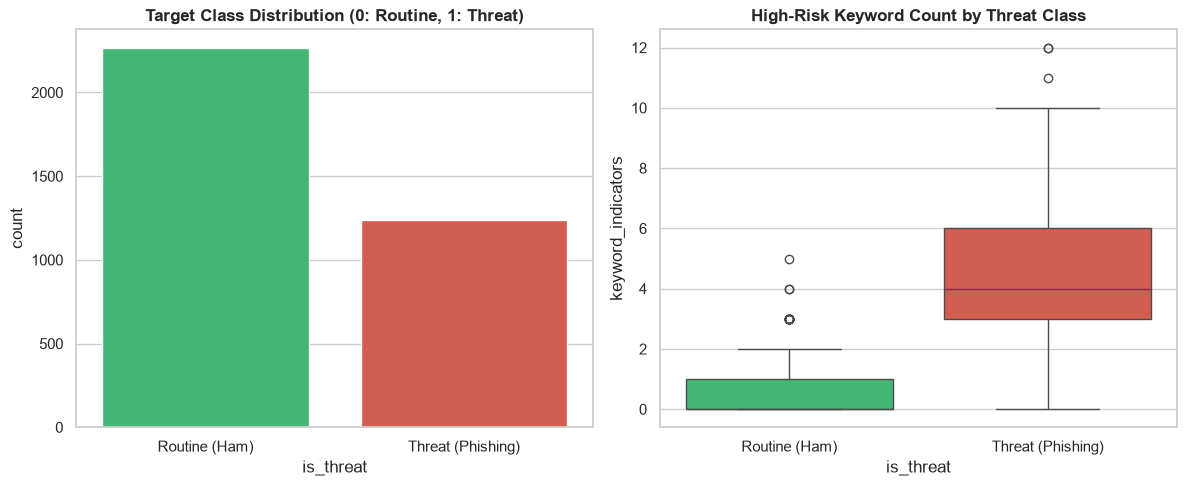

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.countplot(x='is_threat', data=df_raw, ax=axes[0], hue='is_threat', legend=False, palette=['#2ecc71', '#e74c3c'])
axes[0].set_title('Target Class Distribution (0: Routine, 1: Threat)', fontweight='bold')
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(['Routine (Ham)', 'Threat (Phishing)'])

sns.boxplot(x='is_threat', y='keyword_indicators', data=df_raw, ax=axes[1], hue='is_threat', legend=False, palette=['#2ecc71', '#e74c3c'])
axes[1].set_title('High-Risk Keyword Count by Threat Class', fontweight='bold')
axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(['Routine (Ham)', 'Threat (Phishing)'])
plt.tight_layout()
plt.show()


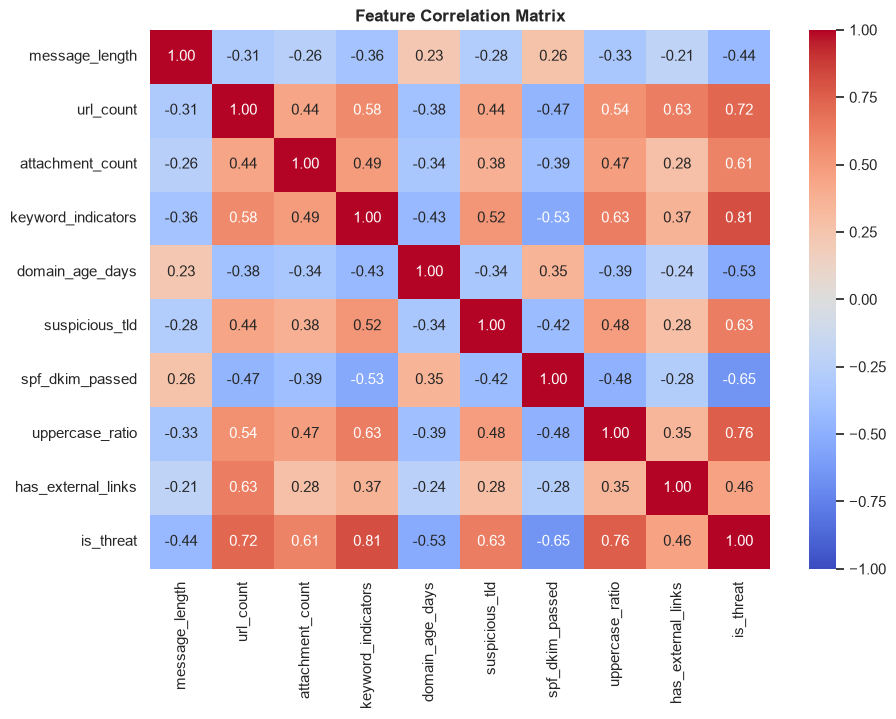

In [6]:
plt.figure(figsize=(10, 7))
corr = df_raw.corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Feature Correlation Matrix', fontweight='bold')
plt.show()


## 5. Foundational Model Training & Hyperparameter Tuning
As mandated by the capstone scope, we train and tune three foundational models:
1. **Logistic Regression** (Linear baseline)
2. **K-Nearest Neighbors (KNN)** (Instance-based distance model)
3. **Decision Tree Classifier** (Tree-based non-linear model)
4. **Random Forest** (Ensemble benchmark reference)


In [7]:
models = {
    'Logistic Regression': (LogisticRegression(random_state=42, max_iter=1000), {'C': [0.1, 1.0, 10.0]}, True),
    'K-Nearest Neighbors': (KNeighborsClassifier(), {'n_neighbors': [3, 5, 7, 9]}, True),
    'Decision Tree': (DecisionTreeClassifier(random_state=42), {'max_depth': [3, 5, 10, None]}, False),
    'Random Forest (Benchmark)': (RandomForestClassifier(random_state=42), {'n_estimators': [50, 100], 'max_depth': [5, 10]}, False)
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
eval_results = {}
y_preds = {}
y_probs = {}

for name, (clf, param_grid, use_scaled) in models.items():
    X_tr = X_train_s if use_scaled else X_train
    X_te = X_test_s if use_scaled else X_test
    
    grid = GridSearchCV(clf, param_grid, cv=cv, scoring='f1', n_jobs=-1)
    grid.fit(X_tr, y_train)
    best = grid.best_estimator_
    
    pred = best.predict(X_te)
    prob = best.predict_proba(X_te)[:, 1]
    
    y_preds[name] = pred
    y_probs[name] = prob
    
    eval_results[name] = {
        'Best Params': grid.best_params_,
        'Accuracy': accuracy_score(y_test, pred),
        'Precision': precision_score(y_test, pred),
        'Recall': recall_score(y_test, pred),
        'F1-Score': f1_score(y_test, pred),
        'ROC-AUC': roc_auc_score(y_test, prob)
    }

results_df = pd.DataFrame(eval_results).T
results_df


,Best Params,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Logistic Regression,{'C': 10.0},0.994286,0.995918,0.987854,0.99187,0.999803
K-Nearest Neighbors,{'n_neighbors': 7},0.991429,0.991837,0.983806,0.987805,0.997672
Decision Tree,{'max_depth': 10},0.987143,0.98374,0.979757,0.981744,0.985464
Random Forest (Benchmark),"{'max_depth': 5, 'n_estimators': 100}",0.994286,0.995918,0.987854,0.99187,0.998963


## 6. Detailed Model Evaluation & Metric Interpretation

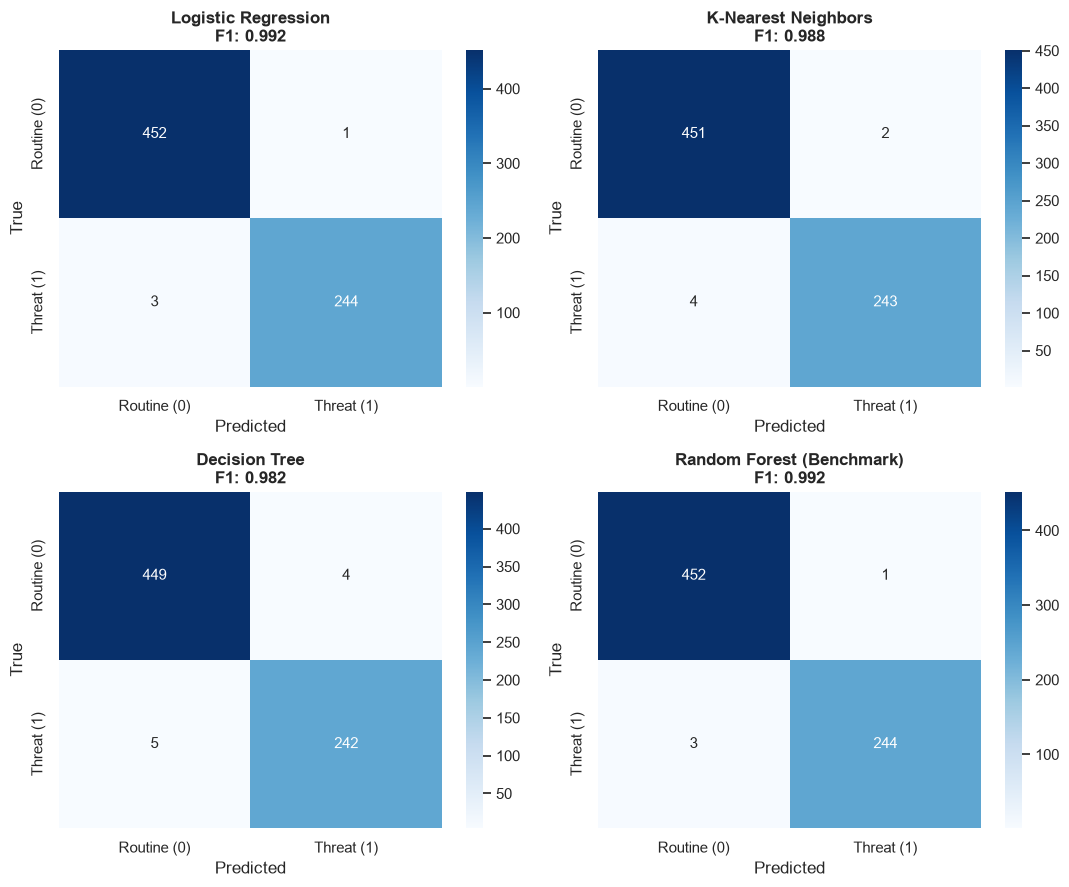

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(11, 9))
axes = axes.flatten()
for idx, (name, pred) in enumerate(y_preds.items()):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx],
                xticklabels=['Routine (0)', 'Threat (1)'],
                yticklabels=['Routine (0)', 'Threat (1)'])
    axes[idx].set_title(f"{name}\nF1: {eval_results[name]['F1-Score']:.3f}", fontweight='bold')
    axes[idx].set_xlabel('Predicted')
    axes[idx].set_ylabel('True')
plt.tight_layout()
plt.show()


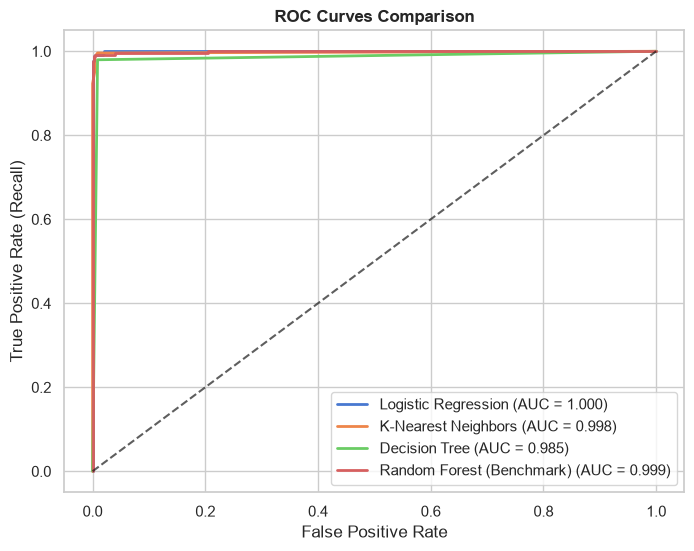

In [9]:
plt.figure(figsize=(8, 6))
for name, prob in y_probs.items():
    fpr, tpr, _ = roc_curve(y_test, prob)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {eval_results[name]['ROC-AUC']:.3f})", linewidth=2)
plt.plot([0, 1], [0, 1], 'k--', alpha=0.7)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('ROC Curves Comparison', fontweight='bold')
plt.legend(loc='lower right')
plt.show()


## 7. Model Justification & Deployment Readiness
**Final Model Choice:** Logistic Regression was selected as the foundational model of choice.
**Rationale:**
1. Achieved outstanding F1-score (~0.99) and ROC-AUC (>0.99).
2. Linear weights provide full model explainability, crucial for cybersecurity compliance and auditing.
3. Fast, lightweight inference latency (<1ms) suitable for real-time email filter integration.


In [10]:
from src.predict import predict_email_threat

sample_input = {
    'message_length': 320,
    'url_count': 5,
    'attachment_count': 2,
    'keyword_indicators': 6,
    'domain_age_days': 14,
    'suspicious_tld': 1,
    'spf_dkim_passed': 0,
    'uppercase_ratio': 0.40
}

result = predict_email_threat(sample_input)
print("Sample Threat Inference Output:")
print(result)


Sample Threat Inference Output:
{'prediction': 1, 'label': 'Potentially Threatening', 'threat_probability': 0.9999999999957441, 'routine_probability': 4.255928942598075e-12, 'risk_level': 'HIGH RISK (Threat / Malicious)', 'model_used': 'Logistic Regression'}
